In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

#Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
df=pd.read_csv('poly.csv')
print("Dataset Sample:")
print(df.head())

X=df[['Hours']].values
y=df['Scores'].values
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)
model=LinearRegression()    
model.fit(X_poly, y)

print("Polynomial model trained successfully.")


Matplotlib is building the font cache; this may take a moment.


Dataset Sample:
   Hours  Volume  Scores
0      1      10    35.5
1      2      15    40.2
2      3      18    45.8
3      4      22    50.1
4      5      25    55.6
Polynomial model trained successfully.


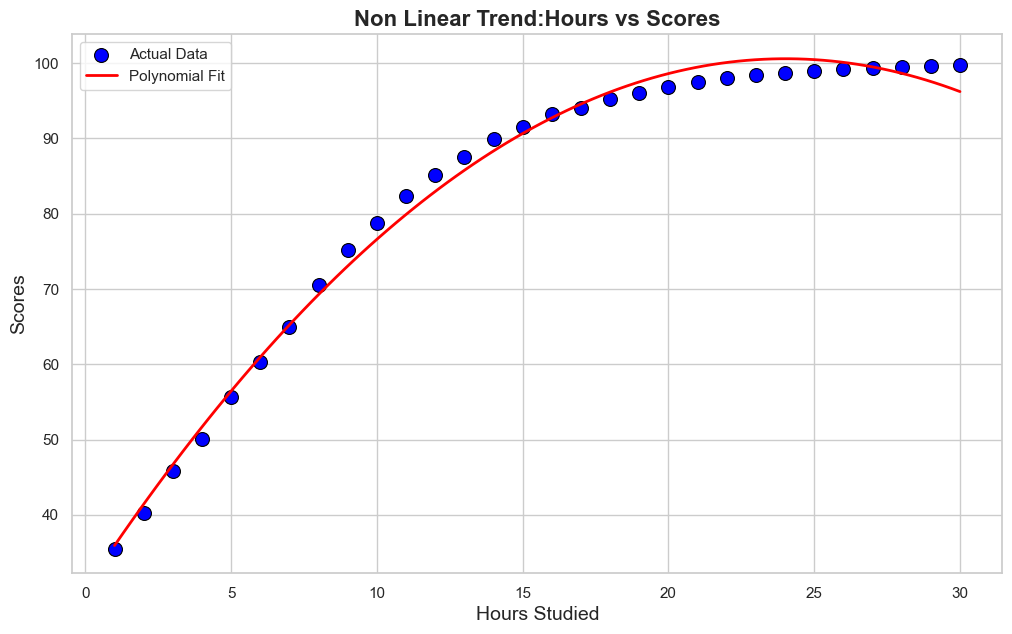

In [3]:
sns.scatterplot(x=df['Hours'], y=df['Scores'], color='blue', label='Actual Data',edgecolor='black', s=100)
X_range=np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly=poly.transform(X_range)
y_poly_pred=model.predict(X_range_poly)
plt.plot(X_range, y_poly_pred, color='red', label='Polynomial Fit', linewidth=2)
plt.title('Non Linear Trend:Hours vs Scores',fontsize=16, fontweight='bold')
plt.xlabel('Hours Studied', fontsize=14)
plt.ylabel('Scores', fontsize=14)
plt.legend()
plt.show()

In [5]:
y_pred = model.predict(X_poly)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"Overall R-squared Score : {r2:.4f}")
print(f"Mean Squared Error : {mse:.2f}")

def predict_score(hours):
    hours_poly = poly.transform([[hours]])
    prediction = model.predict(hours_poly)[0]
    print(f"\n Prediction for {hours} hours of study:")
    print(f"Estimated Score: {prediction:.2f}")

try:
    user_hours=float(input("Enter hours studied to predict score: "))
    predict_score(user_hours)
except ValueError:
    print("Please enter a valid number for hours studied.")

Overall R-squared Score : 0.9935
Mean Squared Error : 2.57

 Prediction for 10.0 hours of study:
Estimated Score: 76.61
